  Reservation_ID Reservation_Date   Booking_Channel Customer_Segment  \
0   RES-20260001       2026-04-23        Mobile App     New Customer   
1   RES-20260002       2026-03-12        Mobile App     New Customer   
2   RES-20260003       2026-05-09  Partner Platform     New Customer   
3   RES-20260004       2026-04-14        Mobile App     New Customer   
4   RES-20260005       2026-01-14           Website     New Customer   

   Party_Size  Lead_Time_Days     Time_Slot Day_Type  Prior_Reservations  \
0           5               5   Peak Dinner  Weekday                   0   
1           3               8  Early Dinner  Weekday                   0   
2           2               6  Early Dinner  Weekday                   0   
3           3               4   Peak Dinner  Weekend                   0   
4           2               1        Brunch  Weekend                   0   

   Past_No_Show_Count Deposit_Paid Confirmation_Response Loyalty_Member  \
0                   1           No 

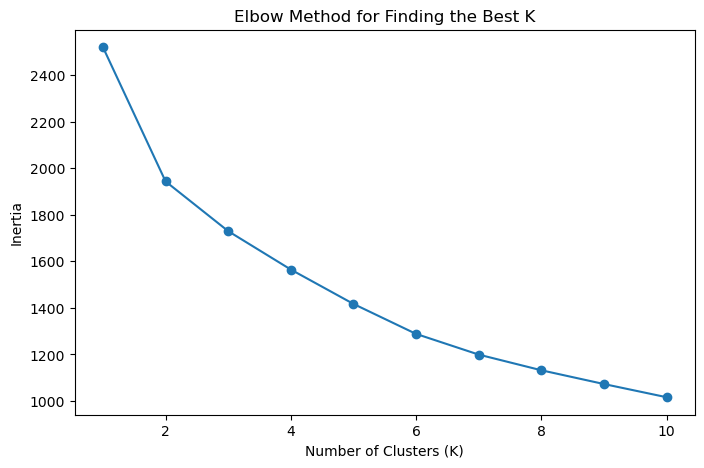

         Party_Size  Lead_Time_Days  Prior_Reservations  Past_No_Show_Count  \
Cluster                                                                       
0              1.91            9.59                4.60                0.13   
1              4.39            9.06                5.61                0.14   
2              2.66            7.66                5.03                1.64   

         Average_Spend_Per_Visit  Distance_From_Restaurant_KM  \
Cluster                                                         
0                          45.02                         9.00   
1                          67.08                         9.42   
2                          53.83                         7.32   

         Reservation_Value_Score  Number_of_Customers  
Cluster                                                
0                          28.90                  175  
1                          86.42                  127  
2                          48.07                   58 

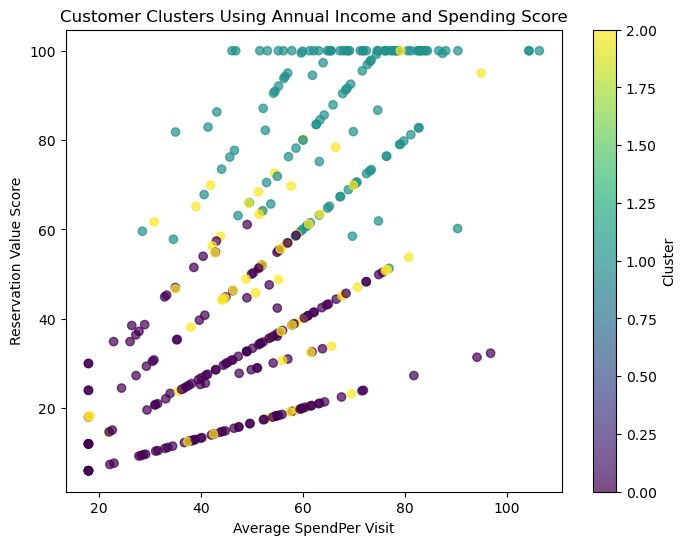

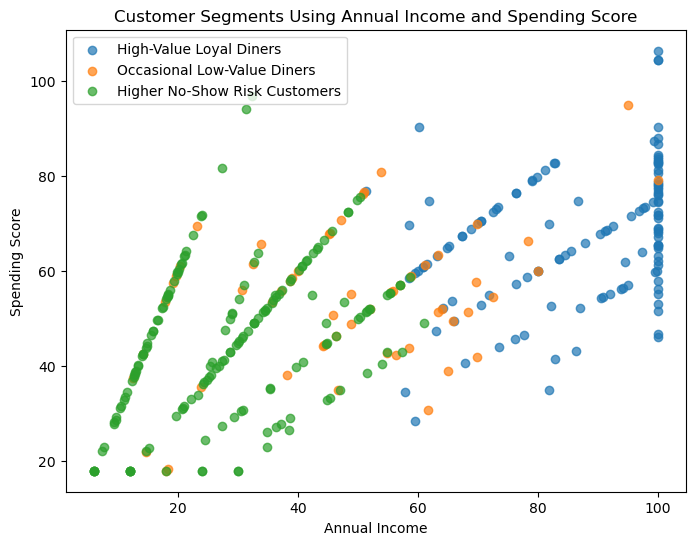

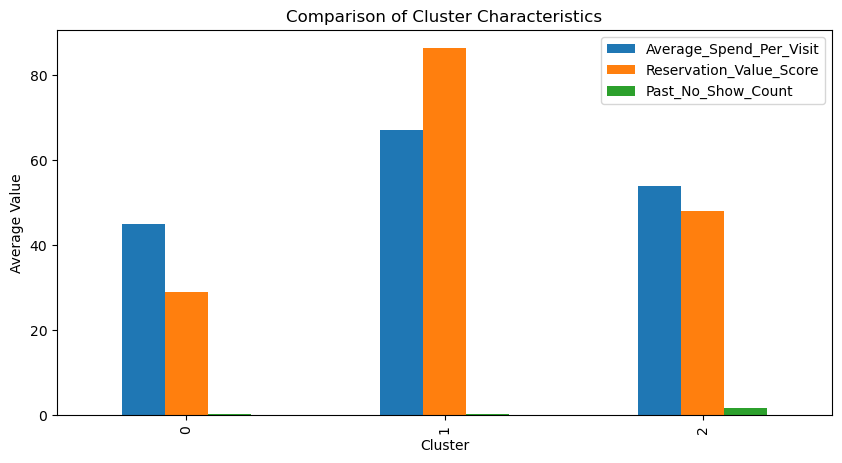

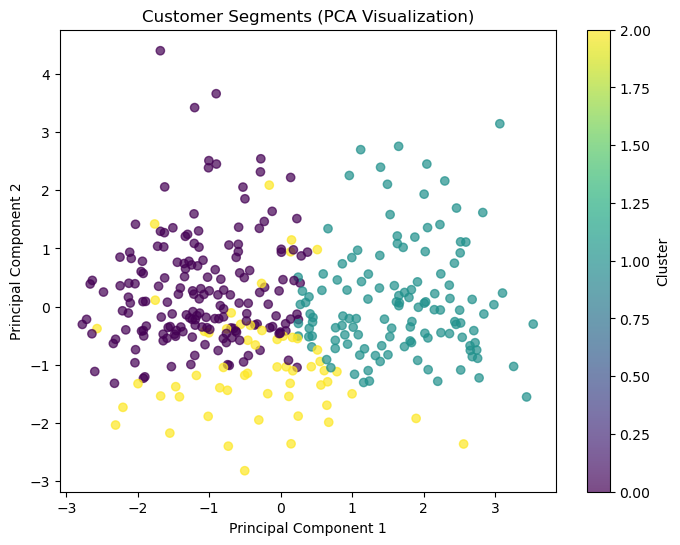

In [109]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# • Load and inspect the dataset
# =========================
# File type is excel but CSV in nature
df = pd.read_excel("tableturn_restaurant_no_show_dataset.xlsx")

print(df.head(), "\n This is the header Information - returns rows 0-4")
print((df.shape), ": This is the shape of the Data")
print((df.columns), " \n : This displays the data Columns")
print((df.info()), ": This shows the data Info")
print(df.describe(), ": This describes the data")
#print(df.isnull().sum(), ": This tells us if there are null data in the set")
#print(df.duplicated().sum(), ": This tells us if there are duplicates in the data set")

# ==================================================
# • Clean the data
# ==================================================


# In this unsupervised learning problem, we only define X.
print("Unsupervised learning: X = features only, no y")

numerical_features = [
    "Party_Size",
    "Lead_Time_Days",
    "Prior_Reservations",
    "Past_No_Show_Count",
    "Average_Spend_Per_Visit",
    "Distance_From_Restaurant_KM",
    "Reservation_Value_Score"
]
print (numerical_features, "these are my numerical_features columns")
X = df[numerical_features]

X.head()

# Check the shape of the selected feature dataset

print("Original dataset shape:", df.shape)
print("Selected features shape:", X.shape)


# Check selected feature names

print("Features selected for clustering:")
for feature in numerical_features:
    print("-", feature)


# Step 8: Clean the Data
# Create a copy of the original dataset
df_clean = df.copy()

# Display original shape
print("Original dataset shape:", df_clean.shape)

# Clean column names by removing extra spaces

df_clean.columns = df_clean.columns.str.strip()

# Display cleaned column names
df_clean.columns

# Check duplicate rows

duplicate_count = df_clean.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)
# Remove duplicate rows
#df_clean = df_clean.drop_duplicates()

# Check missing values before the next step
df_clean.isnull().sum()

# Select numerical columns
numerical_columns = [
    "Party_Size",
    "Lead_Time_Days",
    "Prior_Reservations",
    "Past_No_Show_Count",
    "Average_Spend_Per_Visit",
    "Distance_From_Restaurant_KM",
    "Reservation_Value_Score"
]

# Fill missing values in numerical columns with the median
for col in numerical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Check missing values again
df_clean.isnull().sum()

# Recreate X after cleaning and handling missing values

X = df_clean[numerical_columns]

# Display the selected features
X.head()

# Confirm that there are no missing values in X
X.isnull().sum()



# Step 10: Scale the Features
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()
# Scale the selected features
X_scaled = scaler.fit_transform(X)
# Display the scaled data
X_scaled


# Convert scaled data back to a DataFrame for better readability

X_scaled_df = pd.DataFrame(X_scaled, columns=numerical_columns)
X_scaled_df.head()


# Check the mean and standard deviation after scaling

print("Mean after scaling:")
print(X_scaled_df.mean())

print("\nStandard deviation after scaling:")
print(X_scaled_df.std())

#----------------------------------------------------------------------------------------------------------------------


import pandas as pd

kmeans_intro = pd.DataFrame({
    "Concept": [
        "K-means",
        "K",
        "Cluster",
        "Centroid",
        "Business Use"
    ],
    "Meaning": [
        "An unsupervised learning algorithm used to group similar data points",
        "The number of clusters selected by the user",
        "A group of similar customers or users",
        "The center point of a cluster",
        "Customer segmentation and pattern discovery"
    ]
})

kmeans_intro


# Step 12: Choose the Number of Clusters

import pandas as pd

k_options = pd.DataFrame({
    "K Value": [2, 3, 4, 5, 6],
    "Meaning": [
        "Customers are divided into 2 broad groups",
        "Customers are divided into 3 main groups",
        "Customers are divided into 4 more detailed groups",
        "Customers are divided into 5 smaller groups",
        "Customers are divided into 6 very specific groups"
    ]
})

k_options


# Step 13: Elbow Method for Finding the Best K

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Create an empty list to store inertia values
inertia = []

# Test different values of K
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Finding the Best K")
plt.show()



# Display inertia values for each K

elbow_results = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertia
})

elbow_results



# Step 14: Train the K-means Model

from sklearn.cluster import KMeans

# Create the K-means model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Train the model and assign cluster labels
cluster_labels = kmeans.fit_predict(X_scaled)

# Display the first 10 cluster labels
cluster_labels[:10]

# Check how many customers are in each cluster

import pandas as pd

pd.Series(cluster_labels).value_counts().sort_index()


# Step 15: Add Cluster Labels to the Dataset

# Create a copy of the cleaned dataset
df_clustered = df_clean.copy()

# Add cluster labels to the dataset
df_clustered["Cluster"] = cluster_labels

# Display the first five rows
df_clustered.head()

# Check how many customers are in each cluster

df_clustered["Cluster"].value_counts().sort_index()


# Display selected columns with cluster labels

df_clustered[
    [
    "Party_Size",
    "Lead_Time_Days",
    "Prior_Reservations",
    "Past_No_Show_Count",
    "Average_Spend_Per_Visit",
    "Distance_From_Restaurant_KM",
    "Reservation_Value_Score"
    ] ].head(10)

# Step 16: Analyze Cluster Summary

# Calculate the average value of each feature for each cluster
cluster_summary = df_clustered.groupby("Cluster")[numerical_columns].mean()

# Display the cluster summary
cluster_summary


# Round the values for easier interpretation
cluster_summary_rounded = cluster_summary.round(2)
cluster_summary_rounded

# Count the number of customers in each cluster
cluster_counts = df_clustered["Cluster"].value_counts().sort_index()
cluster_counts

# Create a summary table with customer counts and average feature values
cluster_summary_final = cluster_summary_rounded.copy()
cluster_summary_final["Number_of_Customers"] = cluster_counts
cluster_summary_final
print (cluster_summary_final)

#-----------------------------


# Identify clusters based on customer behavior

summary = cluster_summary_final.copy()

# Cluster with the highest spending score
#high_spender_cluster = summary["Spending_Score"].idxmax()
Reserv_Score_cluster = summary["Reservation_Value_Score"].idxmax()


# Cluster with the highest income among the remaining clusters
#remaining_clusters = summary.drop(index=high_spender_cluster)
remaining_clusters = summary.drop(index=Reserv_Score_cluster)


#premium_cluster = remaining_clusters["Annual_Income"].idxmax()
Avg_Big_Spender = remaining_clusters["Average_Spend_Per_Visit"].idxmax()

# The remaining cluster is considered low engagement / low spending
low_engagement_cluster = summary.drop(index=[Reserv_Score_cluster, Avg_Big_Spender]).index[0]

# Create business names for clusters
segment_names = {
    #high_spender_cluster: "Active High Spenders",
    #premium_cluster: "High-Income Premium Buyers",
    #low_engagement_cluster: "Higher No-Show Risk Customers"

    Reserv_Score_cluster: "High-Value Loyal Diners",
    Avg_Big_Spender: "Occasional Low-Value Diners",
    low_engagement_cluster: "Higher No-Show Risk Customers"
}

# Add segment names to the dataset
df_clustered["Segment_Name"] = df_clustered["Cluster"].map(segment_names)

# Display the first rows
df_clustered.head()




#------------------------------------------------#

# Create an interpretation table

segment_interpretation = pd.DataFrame({
    "Cluster": list(segment_names.keys()),
    "Segment Name": list(segment_names.values()),
    "Business Interpretation": [
        "Customers with high Reservation Value Mark / Count.",
        "Customers with high Average Spend Per Visit",
        "Customers with lower Reservation Score, Less spend, No show, or lower purchase activity."
    ],
    "Possible Business Strategy": [
        "Offer loyalty rewards, personalized promotions, and exclusive campaigns.",
        "Offer premium products, VIP services, and high-value recommendations.",
        "Use reactivation campaigns, discounts, and engagement emails."
    ]
})

segment_interpretation


# Check how many customers are in each named segment
df_clustered["Segment_Name"].value_counts()


# Step 18: Visualize Clusters Using Two Features

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(

    df_clustered["Average_Spend_Per_Visit"],
    df_clustered["Reservation_Value_Score"],
    c=df_clustered["Cluster"],
    alpha=0.7
)

plt.xlabel("Average SpendPer Visit")
plt.ylabel("Reservation Value Score")
plt.title("Customer Clusters Using Annual Income and Spending Score")
plt.colorbar(label="Cluster")
plt.show()


# Visualize clusters using segment names

plt.figure(figsize=(8, 6))

for segment in df_clustered["Segment_Name"].unique():
    segment_data = df_clustered[df_clustered["Segment_Name"] == segment]
    
    plt.scatter(
        segment_data["Reservation_Value_Score"],
        segment_data["Average_Spend_Per_Visit"],
        label=segment,
        alpha=0.7
    )

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments Using Annual Income and Spending Score")
plt.legend()
plt.show()








cluster_summary_final[
    [
        "Average_Spend_Per_Visit",
        "Reservation_Value_Score",
        "Past_No_Show_Count"
    ]
].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Comparison of Cluster Characteristics")
plt.ylabel("Average Value")
plt.show()






##########################################

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=cluster_labels,
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments (PCA Visualization)")
plt.colorbar(label="Cluster")

plt.show()


# Assistant
This error occurs because the variable `df` (which likely contains your dataset) has not been defined or loaded before you try to use it. The code is trying to reference `df` somewhere to create the features or datasets, but `df` doesn't exist in the current namespace.

**Explanation:**
The code appears to be missing the initial steps where you would typically:
1. Import necessary libraries
2. Load your dataset into a DataFrame called `df`
3. Define `numerical_features`, `categorical_features`, `X_train`, `X_test`, `y_train`, etc.

Would you like me to provide the corrected code that includes the missing setup steps?